In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../resources/datasets/reported.csv")

num_cols = df.select_dtypes('number').columns
cat_cols = df.select_dtypes('object').columns

print(df.shape)
df

(66, 21)


,Year,crimes.total,crimes.penal.code,crimes.person,murder,assault,sexual.offenses,rape,stealing.general,burglary,...,vehicle.theft,out.of.vehicle.theft,shop.theft,robbery,fraud,criminal.damage,other.penal.crimes,narcotics,drunk.driving,population
0,1950,2784,2306,120,1,105,40,5,1578,295,...,NaN,NaN,NaN,3,209,72,477,0.0,49,7014000
1,1951,3284,2754,125,1,109,45,6,1899,342,...,NaN,NaN,NaN,3,310,73,530,0.0,66,7073000
2,1952,3160,2608,119,1,104,39,4,1846,372,...,NaN,NaN,NaN,3,217,82,553,0.0,78,7125000
3,1953,2909,2689,119,1,105,45,5,1929,361,...,NaN,NaN,NaN,4,209,88,220,0.0,91,7171000
4,1954,3028,2791,126,1,107,41,5,1981,393,...,NaN,NaN,NaN,4,236,101,237,0.0,103,7213000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2011,14988,12267,1005,2,947,181,69,5783,995,...,213.0,706.0,663.0,103,1220,1774,2721,946.0,314,9449000
62,2012,14734,12148,974,2,914,178,66,5613,922,...,169.0,655.0,635.0,97,1356,1600,2586,994.0,286,9519000
63,2013,14603,12072,896,3,837,184,63,5552,888,...,159.0,543.0,509.0,87,1545,1470,2532,1002.0,279,9644000
64,2014,14890,12305,923,3,859,210,69,5572,913,...,147.0,542.0,505.0,86,1610,1559,2585,983.0,271,9747000


In [3]:
df.dtypes

Year                      int64
crimes.total              int64
crimes.penal.code         int64
crimes.person             int64
murder                    int64
assault                   int64
sexual.offenses           int64
rape                      int64
stealing.general          int64
burglary                  int64
house.theft             float64
vehicle.theft           float64
out.of.vehicle.theft    float64
shop.theft              float64
robbery                   int64
fraud                     int64
criminal.damage           int64
other.penal.crimes        int64
narcotics               float64
drunk.driving             int64
population                int64
dtype: object

<h1><b>Data Visualization</b></h1>

**Line Chart**
<p>Crimes rate and burglary in Year<p>

<Axes: xlabel='Year', ylabel='crimes.total'>

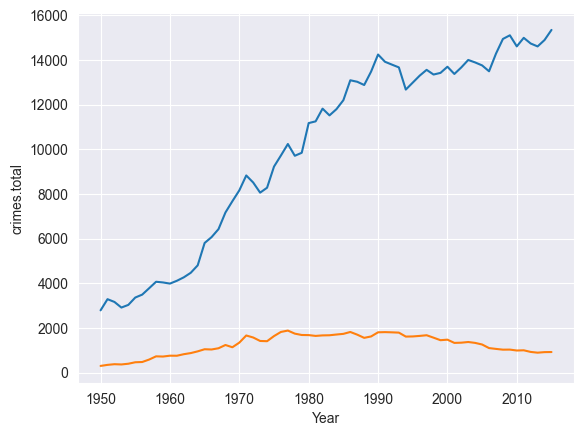

In [4]:
sns.lineplot(data=df, x='Year', y="crimes.total")
sns.lineplot(data=df, x='Year', y="burglary")

**Stack chart or density chart**
<p>Assault per year</p>

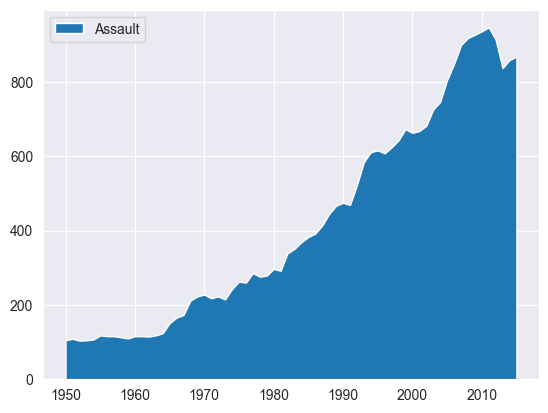

In [5]:
plt.stackplot(df['Year'], df['assault'])
plt.legend(loc='upper left', labels=['Assault'])
plt.show()

**ScatterPlot**
<p>fraud per Year</p>

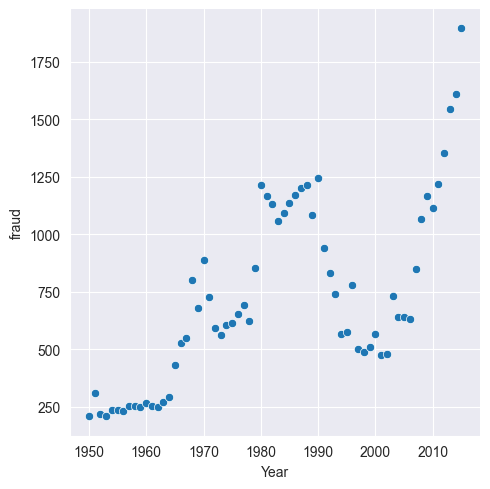

In [6]:
sns.relplot(data=df, x="Year", y='fraud')

**Bar Chart**
<p>House theft per year</p>

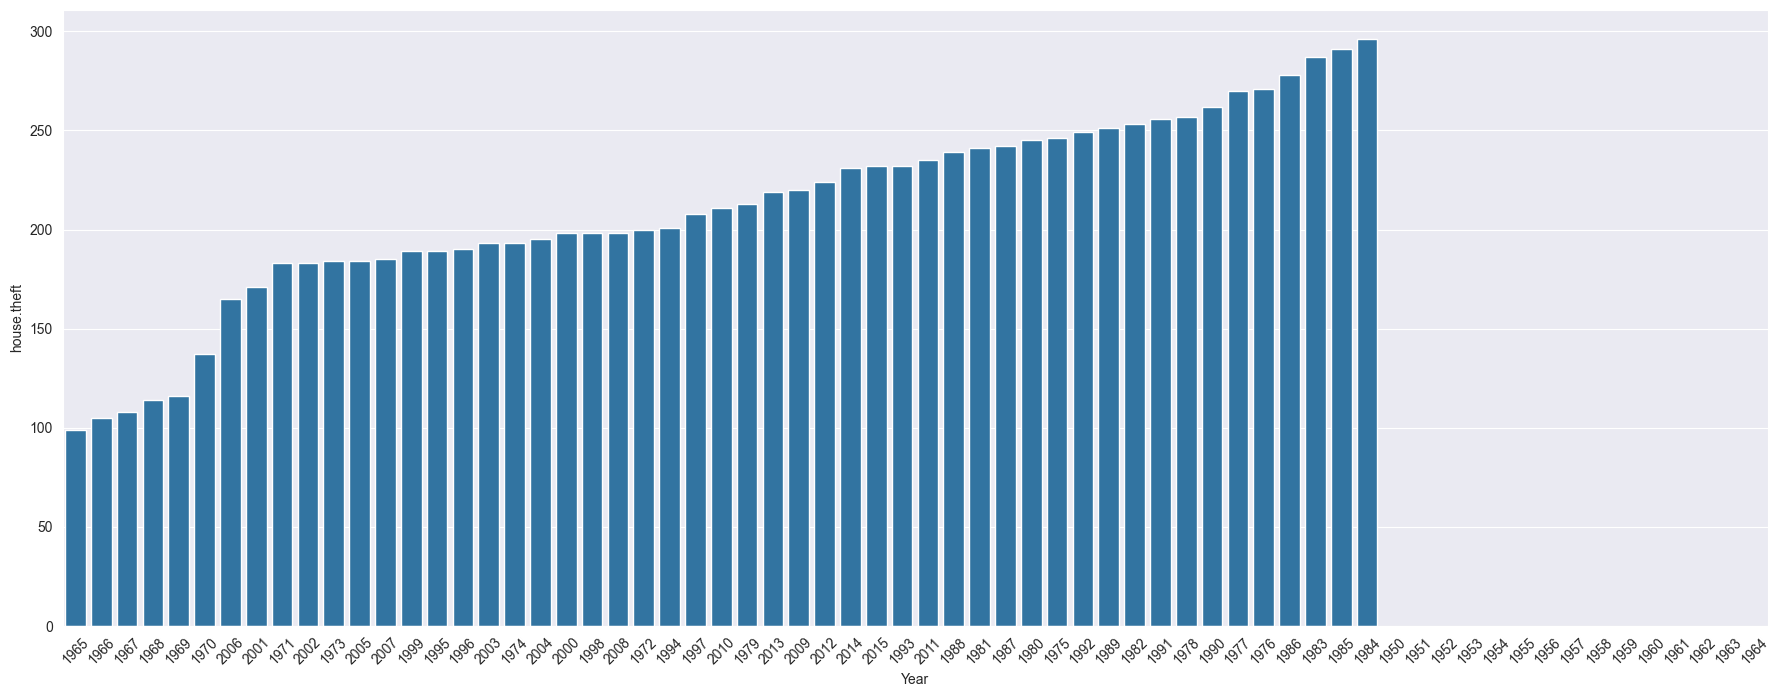

In [7]:
plt.figure(figsize=(22,8))
sns.barplot(data=df, x='Year', y='house.theft', order=df.sort_values(by='house.theft').Year)
plt.xticks(rotation=45)
plt.show()

**Histogram**
<p>Rape per Year</p>

<Axes: xlabel='Year', ylabel='rape'>

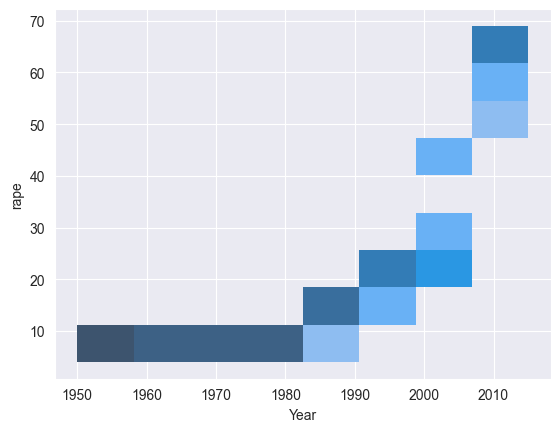

In [8]:
sns.histplot(data=df, x="Year", y="rape")

<h1><b>Data preprocessing(data encoding , handling missing values, handling outliers (detection, removal and replacements) and normalization)</b></h1>

**Cleaning Null value**

In [9]:
df_clearna = df.apply(lambda x: x.fillna(x.mean()))
df_clearna.isnull().sum()

Year                    0
crimes.total            0
crimes.penal.code       0
crimes.person           0
murder                  0
assault                 0
sexual.offenses         0
rape                    0
stealing.general        0
burglary                0
house.theft             0
vehicle.theft           0
out.of.vehicle.theft    0
shop.theft              0
robbery                 0
fraud                   0
criminal.damage         0
other.penal.crimes      0
narcotics               0
drunk.driving           0
population              0
dtype: int64

**Encoding data**

Since there are not object columns in the dataset there is no need to encode the columns

**Outlier detection**

visualization method <br>
the visualization method can be done with boxplots and distribution plot and other plots, boxplots and distribution plot are used below.

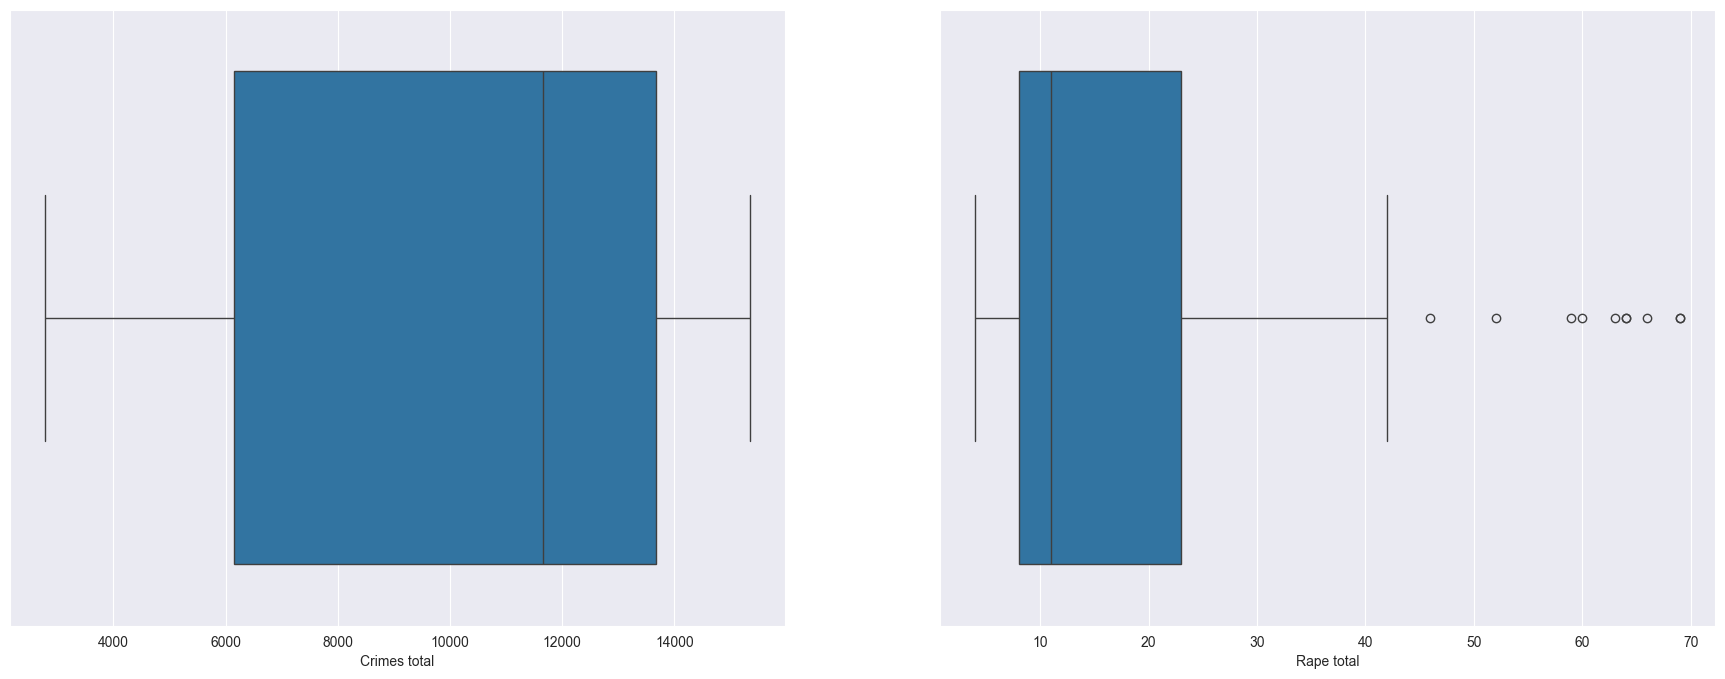

In [10]:
plt.figure(figsize=(22,8))
plt.subplot(1,2,1)
sns.boxplot(df['crimes.total'], orient='h')
plt.xlabel("Crimes total")

plt.subplot(1,2,2)
sns.boxplot(df['rape'], orient='h')
plt.xlabel("Rape total")

plt.show()

**Distribution plot**

C:\Users\User\AppData\Local\Temp\ipykernel_8204\1283984696.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['crimes.total'])
C:\Users\User\AppData\Local\Temp\ipykernel_8204\1283984696.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['rape'])


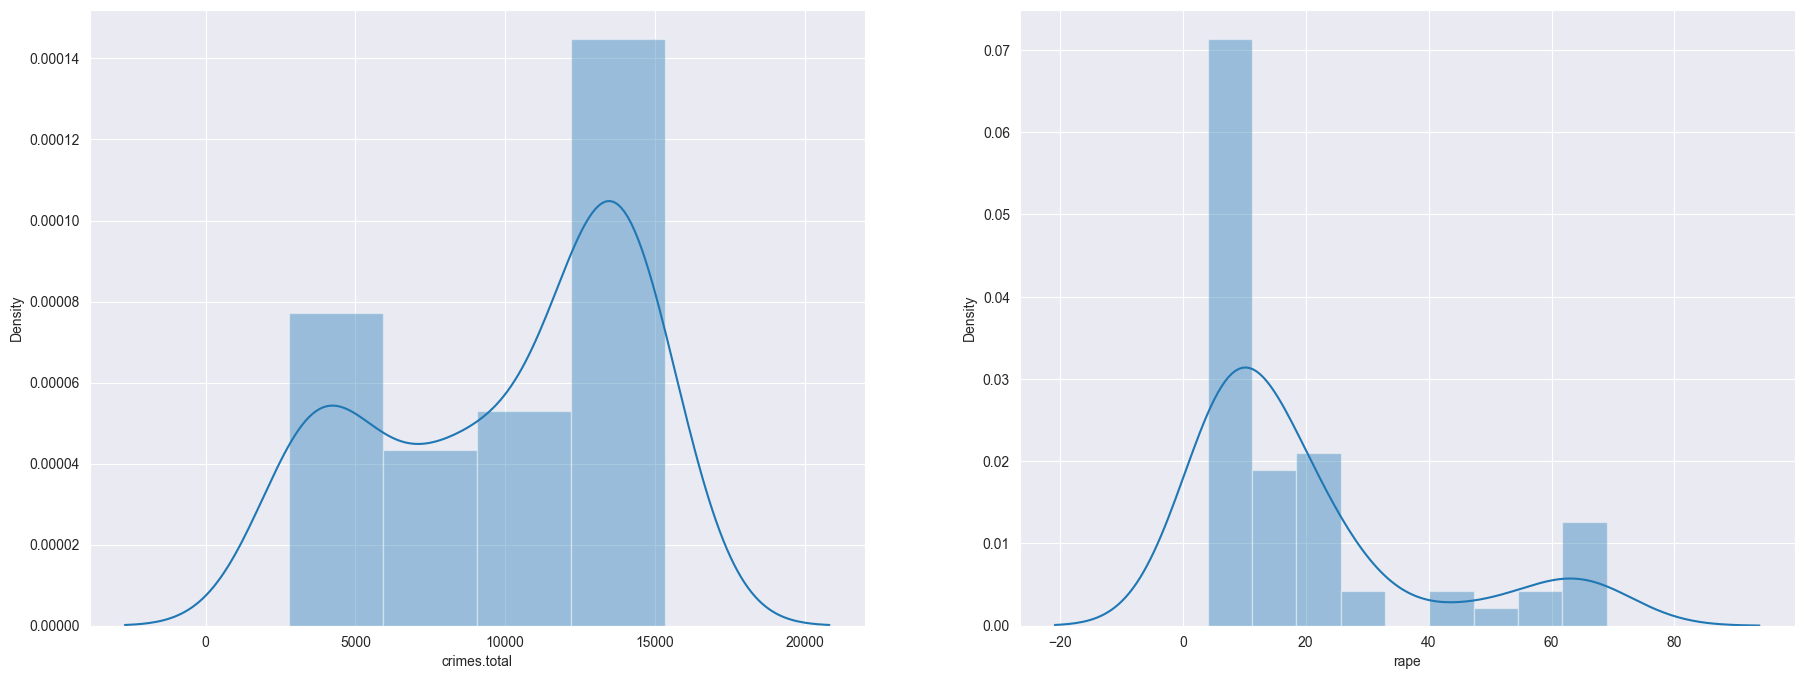

In [11]:
plt.figure(figsize=(22,8))
plt.subplot(1,2,1)
sns.distplot(df['crimes.total'])
plt.subplot(1,2,2)
sns.distplot(df['rape'])
plt.show()

**Z-score detection**<br>
Z score is also known as standard score. Z score tells how many standard deviations away a data point is from the mean, It helps to understand if a data value is greater or smaller than mean and how far away it is from the mean. More specifically.

We calculate the Z-Scores for each column. And set a threshold, which indicates that the data point is quite different from the other data points

In [12]:
df

,Year,crimes.total,crimes.penal.code,crimes.person,murder,assault,sexual.offenses,rape,stealing.general,burglary,...,vehicle.theft,out.of.vehicle.theft,shop.theft,robbery,fraud,criminal.damage,other.penal.crimes,narcotics,drunk.driving,population
0,1950,2784,2306,120,1,105,40,5,1578,295,...,NaN,NaN,NaN,3,209,72,477,0.0,49,7014000
1,1951,3284,2754,125,1,109,45,6,1899,342,...,NaN,NaN,NaN,3,310,73,530,0.0,66,7073000
2,1952,3160,2608,119,1,104,39,4,1846,372,...,NaN,NaN,NaN,3,217,82,553,0.0,78,7125000
3,1953,2909,2689,119,1,105,45,5,1929,361,...,NaN,NaN,NaN,4,209,88,220,0.0,91,7171000
4,1954,3028,2791,126,1,107,41,5,1981,393,...,NaN,NaN,NaN,4,236,101,237,0.0,103,7213000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2011,14988,12267,1005,2,947,181,69,5783,995,...,213.0,706.0,663.0,103,1220,1774,2721,946.0,314,9449000
62,2012,14734,12148,974,2,914,178,66,5613,922,...,169.0,655.0,635.0,97,1356,1600,2586,994.0,286,9519000
63,2013,14603,12072,896,3,837,184,63,5552,888,...,159.0,543.0,509.0,87,1545,1470,2532,1002.0,279,9644000
64,2014,14890,12305,923,3,859,210,69,5572,913,...,147.0,542.0,505.0,86,1610,1559,2585,983.0,271,9747000


In [13]:
# Z Score from outlier detection
from scipy import stats
import numpy as np

z = np.abs(stats.zscore(df_clearna))
z

,Year,crimes.total,crimes.penal.code,crimes.person,murder,assault,sexual.offenses,rape,stealing.general,burglary,...,vehicle.theft,out.of.vehicle.theft,shop.theft,robbery,fraud,criminal.damage,other.penal.crimes,narcotics,drunk.driving,population
0,1.706003,1.741568,1.797285,1.131458,1.053624,1.137329,0.739333,0.791785,1.930388,2.086553,...,3.130444e-16,6.039548e-16,7.048955e-16,1.282193,1.329721,1.344308,1.272781,1.309417,2.684436,1.863711
1,1.653511,1.622287,1.671262,1.114381,1.053624,1.123028,0.634665,0.739159,1.775573,1.982853,...,3.130444e-16,6.039548e-16,7.048955e-16,1.282193,1.072259,1.342644,1.198349,1.309417,2.426255,1.780901
2,1.601019,1.651869,1.712332,1.134873,1.053624,1.140904,0.760266,0.844411,1.801135,1.916661,...,3.130444e-16,6.039548e-16,7.048955e-16,1.282193,1.309328,1.327660,1.166049,1.309417,2.244010,1.707916
3,1.548526,1.711748,1.689546,1.134873,1.053624,1.137329,0.634665,0.791785,1.761105,1.940931,...,3.130444e-16,6.039548e-16,7.048955e-16,1.253739,1.329721,1.317671,1.633703,1.309417,2.046577,1.643353
4,1.496034,1.683359,1.660854,1.110966,1.053624,1.130178,0.718399,0.791785,1.736025,1.870326,...,3.130444e-16,6.039548e-16,7.048955e-16,1.253739,1.260895,1.296029,1.609828,1.309417,1.864332,1.584403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,1.496034,1.169850,1.004757,1.891111,0.337160,1.873085,2.212290,2.576292,0.097642,0.542073,...,1.394892e+00,1.292434e+00,7.608166e-01,1.563293,1.247454,1.489197,1.878615,1.894451,1.340147,1.553950
62,1.548526,1.109255,0.971282,1.785235,0.337160,1.755100,2.149489,2.418413,0.015653,0.703140,...,1.637206e+00,1.427901e+00,5.872074e-01,1.392564,1.594136,1.199520,1.689026,2.057015,0.914908,1.652199
63,1.601019,1.078003,0.949903,1.518839,1.727944,1.479801,2.275090,2.260535,0.013767,0.778158,...,1.692277e+00,1.725398e+00,1.940338e-01,1.108015,2.075923,0.983095,1.613190,2.084109,0.808598,1.827644
64,1.653511,1.146470,1.015446,1.611053,1.727944,1.558458,2.819361,2.576292,0.004121,0.722998,...,1.758363e+00,1.728054e+00,2.188351e-01,1.079560,2.241616,1.131263,1.687622,2.019761,0.687101,1.972210


In [14]:
threshold = 2

# Position of the outliers
np.where(z > threshold)

(array([ 0,  0,  1,  2,  3, 15, 15, 16, 16, 17, 17, 18, 19, 34, 40, 58, 58,
        59, 59, 60, 60, 60, 61, 61, 62, 62, 62, 63, 63, 63, 63, 64, 64, 64,
        64, 65, 65, 65, 65], dtype=int64),
 array([ 9, 19, 19, 19, 19, 10, 13, 10, 13, 10, 13, 10, 10, 10, 11,  7, 16,
         7, 16,  4,  6,  7,  6,  7,  6,  7, 18,  6,  7, 15, 18,  6,  7, 15,
        18,  6,  7, 15, 20], dtype=int64))

**Interquartile range**

IQR is used to measure variability by dividing a data set into quartiles. Q1, Q2, Q3 called first, second and third quartiles are the values for splitting the dataset.

- Q1 represents the 25th percentile of the data.
- Q2 represents the 50th percentile of the data.
- Q3 represents the 75th percentile of the data.

IQR is the range between the first and the third quartiles namely Q1 and Q3: IQR = Q3 — Q1. The data points which fall below Q1–1.5 IQR or above Q3 + 1.5 IQR are outliers.

In [15]:
# IQR
Q1 = np.percentile(df_clearna, 25, method='midpoint')
Q3 = np.percentile(df_clearna, 75, method='midpoint')
IQR = Q3 - Q1

In [16]:
# Above upper bound
upper = df_clearna >= (Q3+1.5*IQR)

print("Upper bound")
upper

Upper bound


,Year,crimes.total,crimes.penal.code,crimes.person,murder,assault,sexual.offenses,rape,stealing.general,burglary,...,vehicle.theft,out.of.vehicle.theft,shop.theft,robbery,fraud,criminal.damage,other.penal.crimes,narcotics,drunk.driving,population
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,False,True,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
62,False,True,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
63,False,True,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
64,False,True,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [17]:
np.where(upper)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 13, 14, 14,
        15, 15, 15, 16, 16, 16, 17, 17, 17, 18, 18, 18, 19, 19, 19, 20, 20,
        20, 20, 21, 21, 21, 21, 22, 22, 22, 22, 23, 23, 23, 23, 24, 24, 24,
        24, 25, 25, 25, 25, 26, 26, 26, 26, 27, 27, 27, 27, 28, 28, 28, 28,
        29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 32, 32, 32, 32, 33,
        33, 33, 33, 34, 34, 34, 34, 35, 35, 35, 35, 36, 36, 36, 36, 37, 37,
        37, 37, 38, 38, 38, 38, 39, 39, 39, 39, 40, 40, 40, 40, 41, 41, 41,
        41, 42, 42, 42, 42, 43, 43, 43, 43, 44, 44, 44, 44, 45, 45, 45, 45,
        46, 46, 46, 46, 47, 47, 47, 47, 48, 48, 48, 48, 49, 49, 49, 49, 50,
        50, 50, 50, 51, 51, 51, 51, 52, 52, 52, 52, 53, 53, 53, 53, 54, 54,
        54, 54, 55, 55, 55, 55, 56, 56, 56, 56, 57, 57, 57, 57, 58, 58, 58,
        58, 59, 59, 59, 59, 60, 60, 60, 60, 61, 61, 61, 61, 62, 62, 62, 62,
        63, 63, 63, 63, 64, 64, 64, 64, 65, 65, 65, 65], dtype=int64),
 array([20, 20, 2

In [18]:
lower = df_clearna <= (Q3-1.5*IQR)

print("Lower bound")
lower

Lower bound


,Year,crimes.total,crimes.penal.code,crimes.person,murder,assault,sexual.offenses,rape,stealing.general,burglary,...,vehicle.theft,out.of.vehicle.theft,shop.theft,robbery,fraud,criminal.damage,other.penal.crimes,narcotics,drunk.driving,population
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
62,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
63,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
np.where(lower)

(array([], dtype=int64), array([], dtype=int64))

**Removing outliers**

In the previous section, we saw how one can detect the outlier using Z-score, and inter quartile range , but now we want to remove or filter the outliers and get the clean data.

We now a new shape of (47,21) after removal with Z-score.

We now a new shape of (51,21) after removal with inter-quartile range.

We can also replace outlier with median value of columns as shown below.

**Remove Outliers**<br>

***Remove with Z-Score***

In [20]:
d=df_clearna[(np.abs(stats.zscore(df_clearna)) < 2 ).all(axis=1)]
d.shape

(47, 21)

***Remove with interquatile range***

In [21]:
Q1 = df_clearna.quantile(0.25)
Q2 = df_clearna.quantile(0.75)
IQR = np.abs(Q3 - Q1)

print(np.abs(IQR))

k = df_clearna[~((df_clearna <= (Q1 - 1.5 * IQR)) | (df_clearna >= (Q3 + 1.5 * IQR))).any(axis=1)]
k.shape

Year                         79.25
crimes.total               4265.50
crimes.penal.code          3449.00
crimes.person              1701.75
murder                     1886.00
assault                    1719.25
sexual.offenses            1846.00
rape                       1879.00
stealing.general           1899.75
burglary                    968.75
house.theft                1694.00
vehicle.theft              1536.50
out.of.vehicle.theft       1020.75
shop.theft                 1423.25
robbery                    1873.75
fraud                      1410.50
criminal.damage            1585.75
other.penal.crimes         1070.25
narcotics                  1668.50
drunk.driving              1709.00
population              7821113.00
Name: 0.25, dtype: float64


(20, 21)

***Replace outliers with median***

In [22]:
ddd=df.drop(['murder'], axis=1)
median = ddd.median()
std = ddd.std()
outliers = (ddd - median).abs() > std

ddd[outliers] = np.nan

h=ddd.fillna(median)
h.shape

(66, 20)

**Normalization with minmax scalar**

Min-max normalization is one of the most common ways to normalize data. For every feature, the minimum value of that feature gets transformed into a 0, the maximum value gets transformed into a 1, and every other value gets transformed into a decimal between 0 and 1.

In [23]:
# Normalize data
from sklearn.preprocessing import MinMaxScaler

# Normalize before dropping the target columns in other to use for correlation feature selection
mms = MinMaxScaler()

drpped = h
dfencoded = np.array(df_clearna['murder']).reshape(-1,1)

scaled_val = mms.fit_transform(drpped)

print(np.shape(scaled_val))

scaled_val[:5]

(66, 20)


array([[0.5       , 0.51922826, 0.51745161, 0.00186567, 0.00192308,
        0.15942029, 0.04      , 0.48797841, 0.49331849, 0.5       ,
        0.5260274 , 0.51282051, 0.53665689, 0.50724638, 0.56277056,
        0.5021645 , 0.49626866, 0.56844106, 0.48412698, 0.48648649],
       [0.5       , 0.51922826, 0.51745161, 0.01119403, 0.00961538,
        0.23188406, 0.08      , 0.48797841, 0.49331849, 0.5       ,
        0.5260274 , 0.51282051, 0.53665689, 0.50724638, 0.08658009,
        0.5021645 , 0.49626866, 0.56844106, 0.48412698, 0.48648649],
       [0.5       , 0.51922826, 0.51745161, 0.        , 0.        ,
        0.14492754, 0.        , 0.48797841, 0.49331849, 0.5       ,
        0.5260274 , 0.51282051, 0.53665689, 0.50724638, 0.56277056,
        0.5021645 , 0.49626866, 0.56844106, 0.48412698, 0.48648649],
       [0.5       , 0.51922826, 0.51745161, 0.        , 0.00192308,
        0.23188406, 0.04      , 0.48797841, 0.49331849, 0.5       ,
        0.5260274 , 0.51282051, 0.53665689, 0

<h1><b>feature selection with filter , embedded and wrapper methods.</b></h1>
Feature selection is also known as attribute selection is a process of extracting the most relevant features from the dataset and then applying machine learning algorithms for the better performance of the model. Feature selection usually can lead to better learning performance, higher learning accuracy, lower computational cost, and better model interpretability.


<h3><b>Filter method</b></h3>

In the Filter method, features are selected based on statistical measures. It is independent of the learning algorithm and requires less computational time. Examples are Information gain, chi-square test, Fisher score, correlation coefficient, and variance threshold or ANOVA.


**Chi-square**

Calculate Chi-square between each feature and the target and select the desired number of features with best Chi-square scores. It determines if the association between two categorical variables of the sample would reflect their real association in the population.

In [24]:
from sklearn.feature_selection import SelectKBest, chi2

X = df_clearna.drop(columns=['murder'])
y = df_clearna['murder']

x_norm = MinMaxScaler().fit(X)

print(np.shape(x_norm))

chi_selector = SelectKBest(chi2, k=10)
chi_training_features = chi_selector.fit_transform(X, y)

print(np.shape(chi_training_features))

chi_support = chi_selector.get_support()
chi_feature = X.loc[:, chi_support].columns.tolist()

print("Original feature number: ", X.shape[1])
print(str(len(chi_feature)), 'selected features')
chi_feature

()
(66, 10)
Original feature number:  20
10 selected features


['crimes.total',
 'crimes.penal.code',
 'crimes.person',
 'assault',
 'stealing.general',
 'fraud',
 'criminal.damage',
 'other.penal.crimes',
 'narcotics',
 'population']

**Pearson correlation**

Correlation is a measure of the linear relationship of 2 or more variables. Through correlation, we can predict one variable from the other. The logic behind using correlation for feature selection is that the good variables are highly correlated with the target.

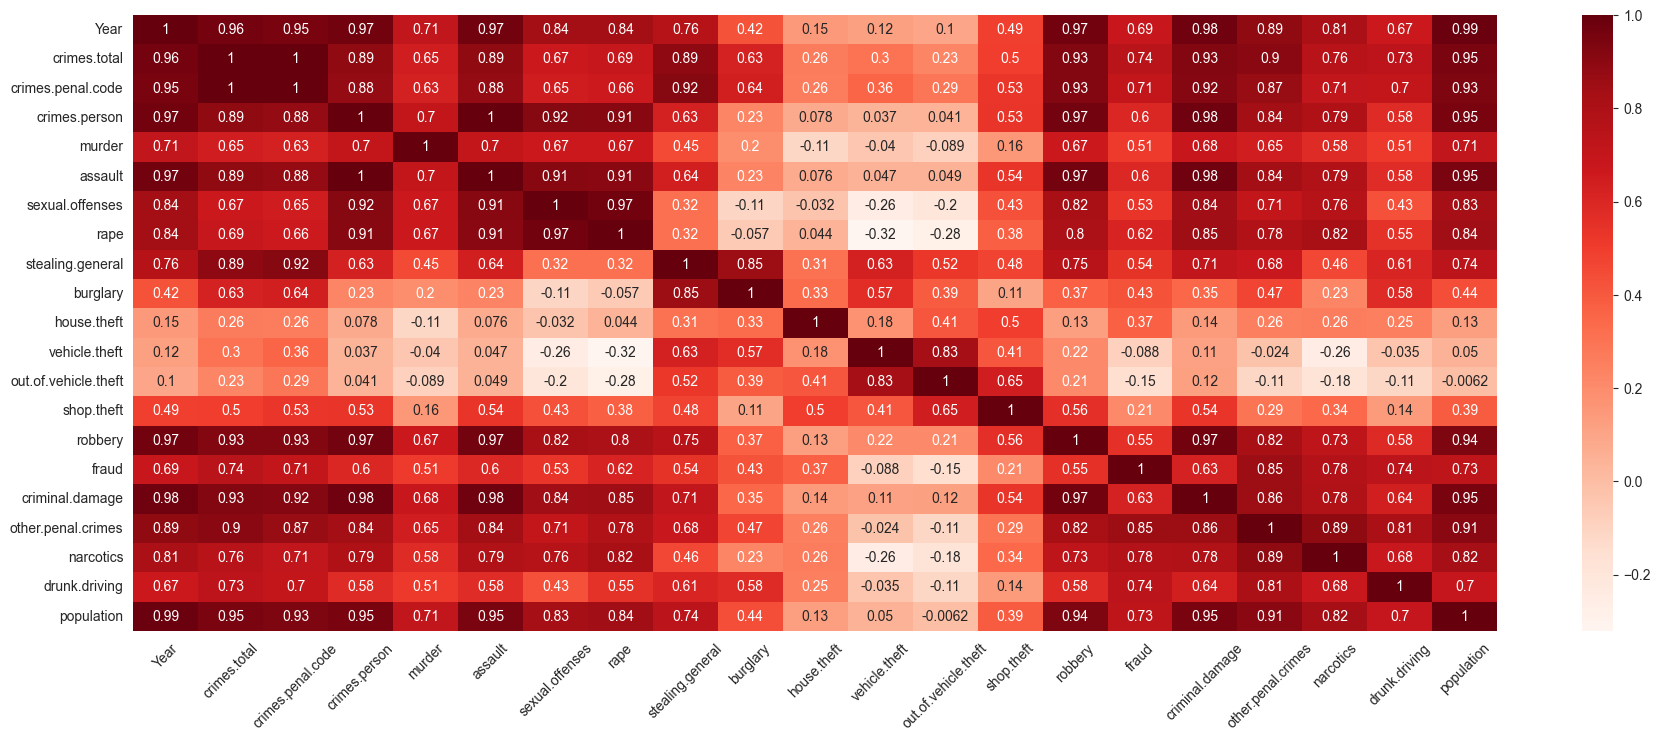

In [25]:
plt.figure(figsize=(22, 8))
sns.heatmap(df_clearna.corr(), annot=True, cmap=plt.cm.Reds)
plt.xticks(rotation=45)
plt.show()

In [26]:
# Correlation with output variabel
cor_target = abs(df_clearna.corr()['murder'])
relevant_feature = cor_target[cor_target > 0.5]
# Selecting highly correlation features
print("Original feature number: ", df_clearna.shape[1])
print("The relevant features length: ", len(relevant_feature))
print("The relevant features are: ")
relevant_feature.sort_values(ascending=False)

Original feature number:  21
The relevant features length:  15
The relevant features are: 


murder                1.000000
population            0.712011
Year                  0.711252
crimes.person         0.703834
assault               0.702906
criminal.damage       0.682365
sexual.offenses       0.674073
rape                  0.669512
robbery               0.667353
other.penal.crimes    0.647027
crimes.total          0.645602
crimes.penal.code     0.631088
narcotics             0.581683
drunk.driving         0.513687
fraud                 0.505537
Name: murder, dtype: float64

**Information gain**

It is commonly used in the construction of decision trees from a training dataset, by evaluating the information gain for each variable, and selecting the variable that maximizes the information gain, which in turn minimizes the entropy and best splits the dataset into groups for effective classification.

murder                  0.606550
crimes.person           0.605346
sexual.offenses         0.501713
shop.theft              0.495970
Year                    0.471947
fraud                   0.441711
drunk.driving           0.440932
other.penal.crimes      0.426102
crimes.total            0.408828
crimes.penal.code       0.352381
rape                    0.345364
house.theft             0.331171
stealing.general        0.326085
assault                 0.302676
out.of.vehicle.theft    0.302144
robbery                 0.293165
vehicle.theft           0.284070
criminal.damage         0.275052
narcotics               0.129251
burglary                0.122728
dtype: float64


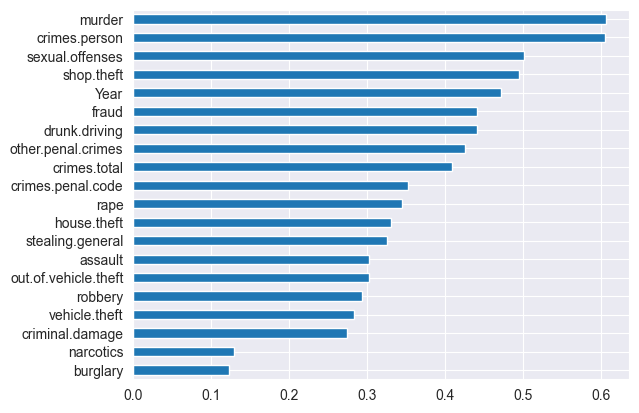

In [27]:
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

# Specify features
res = mutual_info_regression(X, y)
feat_importance = pd.Series(res, df_clearna.columns[0:len(df_clearna.columns)-1]).sort_values()
feat_importance.plot(kind='barh')
print(feat_importance.sort_values(ascending=False))

**ANOVA**

ANOVA is an acronym for analysis of variance and is used for determining whether the means from two or more samples of data (often three or more) come from the same distribution or not. The results of this test can be used for feature selection where those features that are independent of the target variable can be removed from the dataset.

In [28]:
from numpy import set_printoptions
from sklearn.feature_selection import SelectKBest, f_classif

# Features extraction
test = SelectKBest(score_func=f_classif, k=10)
fit = test.fit(X, y)

# Summarize scores
set_printoptions(precision=10)

features = fit.transform(X)
# Summarize selected features
ANOVA_Features_for_training = test.fit_transform(X, y)

print(np.shape(chi_training_features))

ANOVA_support = test.get_support()
ANOVA_feature = X.loc[:,ANOVA_support].columns.tolist()

print("The dataset features are: ", X.shape[1])

print("The selected features with ANOVA(filter Method) are: ", len(ANOVA_feature))
print("The Features are: ")
ANOVA_feature

(66, 10)
The dataset features are:  20
The selected features with ANOVA(filter Method) are:  10
The Features are: 


['Year',
 'crimes.total',
 'crimes.penal.code',
 'crimes.person',
 'assault',
 'stealing.general',
 'robbery',
 'criminal.damage',
 'other.penal.crimes',
 'population']

<h3><b>wrapper method</b></h3>

The Wrapper methodology considers the selection of feature sets as a search problem, where different combinations are prepared, evaluated, and compared to other combinations. A predictive model is used to evaluate a combination of features and assign model performance scores. RFE , Forward selection and backward elimination are used on the dataset.

**RFE**

Recursive feature elimination (RFE) is a feature selection method that fits a model and removes the weakest feature (or features) until the specified number of features is reached. Features are ranked by the model’s coef or feature_importances_ attributes, and by recursively eliminating a small number of features per loop, RFE attempts to eliminate dependencies and collinearity that may exist in the model.

In [29]:
# Using RFE
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE, SelectKBest

model = LinearRegression()

# Init RFE model
rfe = RFE(estimator=model, n_features_to_select=8)

# Transforming data using RFE
rfe_for_training = rfe.fit_transform(X, y)

print(rfe_for_training.shape)

print(rfe.support_)
print(rfe.ranking_)

rfe_support = rfe.get_support()
rfe_feature = X.loc[:, rfe_support].columns.tolist()
print("Original feature number: ", X.shape[1])

print(str(len(rfe_feature)), 'selected feature')
rfe_feature

(66, 8)
[False  True  True  True  True  True  True False False False False False
 False  True False False  True False False False]
[ 4  1  1  1  1  1  1 12  9  3  8  5  2  1 10 11  1  6  7 13]
Original feature number:  20
8 selected feature


['crimes.total',
 'crimes.penal.code',
 'crimes.person',
 'assault',
 'sexual.offenses',
 'rape',
 'robbery',
 'other.penal.crimes']

**Forward selection**

Forward selection is an iterative method in which we start with having no feature in the model. In each iteration, we keep adding the feature which best improves our model till an addition of a new variable does not improve the performance of the model.

In [30]:
# Using forward_selection
# Improving the necessary

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

sfs = SFS(
    estimator=LinearRegression(), 
    k_features=11, 
    forward=False, 
    floating=False, 
    scoring='r2', 
    cv=5
)

sfs.fit(X, y)

backward_features_for_training = sfs.fit_transform(X, y)
print("Original feature number: ", X.shape[1])
print(str(len(sfs.k_feature_names_)), "selected features")
print("They are: ")
sfs.k_feature_names_

TypeError: got an unexpected keyword argument 'fit_params'

<h3><b>Embedded method</b></h3>

These methods encompass the benefits of both the wrapper and filter methods, by including interactions of features but also maintaining reasonable computational cost. Embedded methods are iterative in the sense that takes care of each iteration of the model training process and carefully extracts those features which contribute the most to the training for a particular iteration.



**Lasso Regularization**

Lasso or L1 Regularization consists of adding a penalty to the different parameters of the machine learning model to avoid over-fitting. In linear model regularization, the penalty is applied over the coefficients that multiply each of the predictors. From the different types of regularization, Lasso or L1 has the property that is able to shrink some of the coefficients to zero. Therefore, that feature can be removed from the model.

In [671]:
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
sel_ = SelectFromModel(LogisticRegression(C=1, penalty='l1', solver='liblinear'))
sel_.fit(scaler.transform(X.fillna(0)), y)

lasso_for_training = sel_.fit_transform(X.fillna(0), y)

print(np.shape(lasso_for_training))

sel_support = sel_.get_support()
print(sel_support)

selected_feat = X.columns[(sel_support)]

print('Total features: {}'.format(X.shape[1]))
print("selected features: {}".format(len(selected_feat)))
print(selected_feat)
print("Features with coefficient sharnk to zero: {}".format(np.sum(sel_.estimator_.coef_ == 0)))

(66, 19)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False]
Total features: 20
selected features: 19
Index(['Year', 'crimes.total', 'crimes.penal.code', 'crimes.person', 'assault',
       'sexual.offenses', 'rape', 'stealing.general', 'burglary',
       'house.theft', 'vehicle.theft', 'out.of.vehicle.theft', 'shop.theft',
       'robbery', 'fraud', 'criminal.damage', 'other.penal.crimes',
       'narcotics', 'drunk.driving'],
      dtype='object')
Features with coefficient sharnk to zero: 5


d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


**Ridge Regression**

L2 or ridge regression, on the other hand, is useful when you have collinear/codependent features.Ridge regression adds “squared magnitude” of coefficient as penalty term to the loss function.

In [672]:
scaler = StandardScaler()
scaler.fit(X)
sel_ = SelectFromModel(LogisticRegression(C=1, penalty='l2', solver='liblinear'))
sel_.fit(scaler.transform(X.fillna(0)), y)

lasso_for_training = sel_.fit_transform(X.fillna(0), y)

print(np.shape(lasso_for_training))

sel_support = sel_.get_support()
print(sel_support)

selected_feat = X.columns[(sel_support)]

print('Total features: {}'.format(X.shape[1]))
print("selected features: {}".format(len(selected_feat)))
print(selected_feat)
print("Features with coefficient sharnk to zero: {}".format(np.sum(sel_.estimator_.coef_ == 0)))

(66, 11)
[False  True  True  True False False False  True False  True False  True
  True False  True  True  True  True False False]
Total features: 20
selected features: 11
Index(['crimes.total', 'crimes.penal.code', 'crimes.person',
       'stealing.general', 'house.theft', 'out.of.vehicle.theft', 'shop.theft',
       'fraud', 'criminal.damage', 'other.penal.crimes', 'narcotics'],
      dtype='object')
Features with coefficient sharnk to zero: 0


**Random forest importance**

Feature importance refers to a class of techniques for assigning scores to input features to a predictive model that indicates the relative importance of each feature when making a prediction.

Random Forests is a kind of a Bagging Algorithm that aggregates a specified number of decision trees. The tree-based strategies used by random forests naturally rank by how well they improve the purity of the node, or in other words a decrease in the impurity (Gini impurity) over all trees.

(66, 9)
9 selection features


['Year',
 'crimes.total',
 'crimes.penal.code',
 'crimes.person',
 'assault',
 'house.theft',
 'robbery',
 'criminal.damage',
 'population']

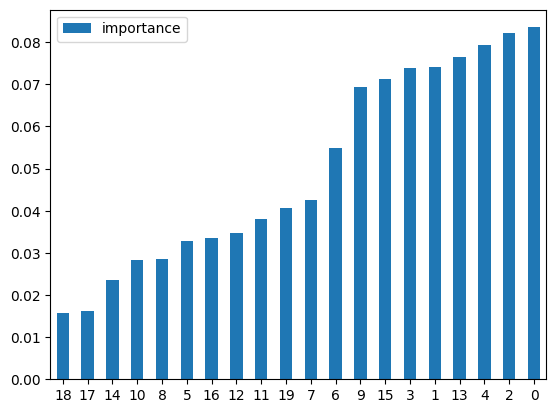

In [673]:
from sklearn.ensemble import RandomForestClassifier

embedded_fr_selector = RandomForestClassifier(n_estimators=100)
embedded_fr_selector.fit(X, y)

importance = embedded_fr_selector.feature_importances_

# DF visualization
final_df=pd.DataFrame({"Features": pd.DataFrame(X).columns, 'importance': importance})
final_df.set_index('importance')

final_df.sort_values('importance', inplace=True)
final_df.plot.bar()
plt.xticks(rotation=0)

# Feature selection
embedded_fr_selector2 = SelectFromModel(RandomForestClassifier(n_estimators=100))
embedded_fr_selector2.fit(X, y)
rf_for_training=embedded_fr_selector2.fit_transform(X, y)

print(np.shape(rf_for_training))

embedded_rf_support = embedded_fr_selector2.get_support()
embedded_rf_feature = X.loc[:,embedded_rf_support].columns.tolist()
print(str(len(embedded_rf_feature)), "selection features")
embedded_rf_feature

**Principle component Analysis (PCA)**

PCA is a dimensionality reduction method. The PCA method can be described and implemented using the tools of linear algebra.The basic idea when using PCA as a tool for feature selection is to select variables according to the magnitude (from largest to smallest in absolute values) of their coefficients (loadings).

In [674]:
# Feature extraction with PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
fit = pca.fit(X)

PCA_features_for_training = fit.transform(X)

# summarize components
print("Explained variance : %s" % fit.explained_variance_ratio_)
fit.components_

Explained variance : [9.9998820981e-01 1.0629833109e-05 5.9479212954e-07 3.8718829841e-07
 7.5184009858e-08]


array([[ 2.6454525031e-05,  5.5728689741e-03,  4.6605920050e-03,
         3.8989124635e-04,  3.7223527777e-04,  5.5873616168e-05,
         2.2521371513e-05,  2.1460647781e-03,  2.7839190160e-04,
         7.5644759591e-06,  1.2747435771e-05, -3.2849759830e-06,
         8.8954026943e-05,  4.6153662509e-05,  4.0148788839e-04,
         8.0199600192e-04,  9.0612038995e-04,  3.4187800349e-04,
         6.4706859571e-05,  9.9997024317e-01],
       [-5.4709404791e-04, -5.6435436268e-01, -5.4203807230e-01,
         7.4906832690e-03,  6.0481292786e-03,  8.1965860914e-03,
         3.2011355181e-03, -5.8667944413e-01, -1.4123942274e-01,
        -7.1427091300e-03, -6.7854843382e-02, -1.2930222621e-01,
        -2.6082052260e-02, -1.8150323736e-03, -1.3641881361e-02,
        -1.5563140551e-02, -2.0688188112e-02,  2.0032487068e-02,
        -4.7548984803e-03,  6.9972457189e-03],
       [ 6.0847048501e-04,  5.3034673110e-01,  9.7311979631e-02,
         4.7478299986e-02,  4.1969026550e-02,  1.1095555078e-

<h1><b>Compare training without feature selection and with feature selection (Filter method(chi-square), wrapper method (RFE), and embedded method(Lasso))</b></h1>

In [675]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor

def get_accuracy_feature_selection(X_, y_, train_s, test_s, rs, name_):
    print(np.shape(X_))
    X_train, X_test, y_train, y_test = train_test_split(X_, y_, test_size=train_s, train_size=test_s, random_state=rs)
    model = GaussianNB()
    model.fit(X_train, y_train)
    model_pred = model.predict(X_test)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"Trining of naive bayes for '{name_}' Feature selection is: ", train_acc)
    print(f"Testing of naive bayes for '{name_}' Feature selection is: ", test_acc)
    
    predictions = model.predict(X_test)
    CM = confusion_matrix(y_test, model_pred)
    print(classification_report(y_test, predictions))

<h3><b>Naïve Bayes training without feature selection</b></h3>

In [676]:
get_accuracy_feature_selection(h,y,0.3,None,None,'without')

(66, 20)
Trining of naive bayes for 'without' Feature selection is:  0.782608695652174
Testing of naive bayes for 'without' Feature selection is:  0.8
              precision    recall  f1-score   support

           1       0.92      0.85      0.88        13
           2       0.62      0.83      0.71         6
           4       0.00      0.00      0.00         1

    accuracy                           0.80        20
   macro avg       0.51      0.56      0.53        20
weighted avg       0.78      0.80      0.79        20



d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<h3><b>Naïve Bayes training with feature selection</b></h3>

**Chi-square**

In [677]:
get_accuracy_feature_selection(chi_training_features,y,0.2,None,None,"chisquare (Filter Method)")

(66, 10)
Trining of naive bayes for 'chisquare (Filter Method)' Feature selection is:  0.8269230769230769
Testing of naive bayes for 'chisquare (Filter Method)' Feature selection is:  0.7142857142857143
              precision    recall  f1-score   support

           1       0.75      0.86      0.80         7
           2       0.60      1.00      0.75         3
           3       1.00      0.25      0.40         4

    accuracy                           0.71        14
   macro avg       0.78      0.70      0.65        14
weighted avg       0.79      0.71      0.67        14



**RFE**

In [678]:
get_accuracy_feature_selection(rfe_for_training,y,0.2,None,None,"RFE (Wrapper method)")

(66, 8)
Trining of naive bayes for 'RFE (Wrapper method)' Feature selection is:  0.7692307692307693
Testing of naive bayes for 'RFE (Wrapper method)' Feature selection is:  0.7142857142857143
              precision    recall  f1-score   support

           1       0.67      0.80      0.73         5
           2       0.67      0.80      0.73         5
           3       1.00      0.50      0.67         4

    accuracy                           0.71        14
   macro avg       0.78      0.70      0.71        14
weighted avg       0.76      0.71      0.71        14



**LASSO**

In [679]:
get_accuracy_feature_selection(lasso_for_training,y,0.2,None,None,"LASSO (Wrapper method)")

(66, 11)
Trining of naive bayes for 'LASSO (Wrapper method)' Feature selection is:  0.7692307692307693
Testing of naive bayes for 'LASSO (Wrapper method)' Feature selection is:  0.7857142857142857
              precision    recall  f1-score   support

           1       1.00      0.71      0.83         7
           2       0.71      0.83      0.77         6
           3       0.50      1.00      0.67         1

    accuracy                           0.79        14
   macro avg       0.74      0.85      0.76        14
weighted avg       0.84      0.79      0.79        14



<h3><b>Time series or regression algorithms comparison (Naïve Bayes, k-nearest neighbor, Support vector machines, Convolutional neural network and RNN(LSTM)</b></h3>

**Naive bayes**

it is an algorithm based on Bayes’ Theorem with an assumption of independence among predictors. In simple terms, a Naive Bayes classifier assumes that the presence of a particular feature in a class is unrelated to the presence of any other feature. Naive Bayes classifier performs better compare to other models like logistic regression and you need less training data

In [680]:
X2 = lasso_for_training
print(np.shape(X2))

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2)

model = GaussianNB()
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training accuracy of naive for lasso (Embedded method) Feature selection is: ", train_acc)
print("Testing accuracy of naive for lasso (Embedded method) Feature selection is: ", test_acc)

(66, 11)
Training accuracy of naive for lasso (Embedded method) Feature selection is:  0.75
Testing accuracy of naive for lasso (Embedded method) Feature selection is:  0.8571428571428571


              precision    recall  f1-score   support

           1       1.00      0.88      0.93         8
           2       0.67      1.00      0.80         4
           3       1.00      0.50      0.67         2

    accuracy                           0.86        14
   macro avg       0.89      0.79      0.80        14
weighted avg       0.90      0.86      0.86        14



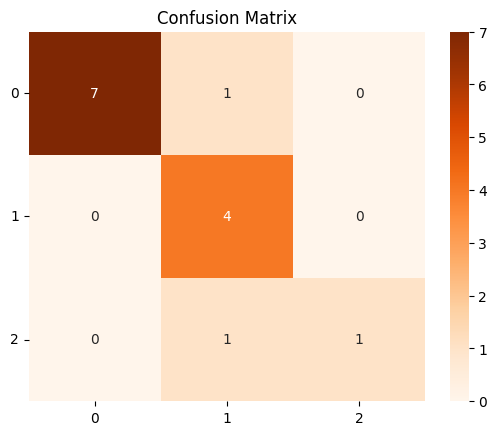

In [681]:
predictions = model.predict(X_test)
CM = confusion_matrix(y_test, predictions)

# To test on another data
ax = plt.subplot()
sns.heatmap(CM,annot=True,fmt='g',ax=ax,cmap=plt.cm.Oranges)
plt.yticks(rotation=0)
ax.set_title("Confusion Matrix")
print(classification_report(y_test, predictions))

**Support Vector Machine (SVM)**

Support Vector Machine can also be used as a regression method, maintaining all the main features that characterize the algorithm (maximal margin). In the case of regression, a margin of tolerance (epsilon) is set in approximation to the SVM which would have already requested from the problem.

In [682]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training accuracy of naive for lasso (Embedded method) Feature selection is: ", train_acc)
print("Testing accuracy of naive for lasso (Embedded method) Feature selection is: ", test_acc)

Training accuracy of naive for lasso (Embedded method) Feature selection is:  0.7692307692307693
Testing accuracy of naive for lasso (Embedded method) Feature selection is:  0.7857142857142857


d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           1       1.00      0.88      0.93         8
           2       0.57      1.00      0.73         4
           3       0.00      0.00      0.00         2

    accuracy                           0.79        14
   macro avg       0.52      0.62      0.55        14
weighted avg       0.73      0.79      0.74        14



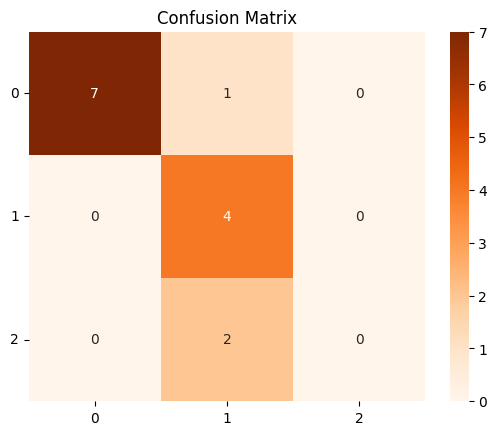

In [683]:
predictions = model.predict(X_test)
CM = confusion_matrix(y_test, predictions)

ax = plt.subplot()
sns.heatmap(CM, annot=True, ax=ax, fmt='g', cmap=plt.cm.Oranges)
plt.yticks(rotation=0)
ax.set_title("Confusion Matrix")

print(classification_report(y_test, predictions))

**Convolutional Neural Network**

Convolutional Neural Network (CNN) models are mainly used for two-dimensional arrays like image data. However, we can also apply CNN with regression data analysis. In this case, we apply a one-dimensional convolutional network and reshape the input data according to it. Keras provides the Conv1D class to add a one-dimensional convolutional layer into the model.

In [684]:
from tensorflow import keras
from sklearn.preprocessing import LabelBinarizer

n_features = 11

model1D = keras.Sequential([
  keras.layers.Dense(76, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)),
  keras.layers.Dense(8, activation='relu', kernel_initializer='he_normal'),
  keras.layers.Dense(4, activation='sigmoid')
])

model1D.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

lb = LabelBinarizer()
yyy=lb.fit_transform(y_train.astype(str))

history=model1D.fit(X_train, yyy, epochs=10, batch_size=8, verbose=1)
print(history)

Epoch 1/10
7/7 [==============================] - 2s 5ms/step - loss: 0.6393 - accuracy: 0.1154
Epoch 2/10
7/7 [==============================] - 0s 5ms/step - loss: 0.4760 - accuracy: 0.1154
Epoch 3/10
7/7 [==============================] - 0s 4ms/step - loss: 0.4423 - accuracy: 0.1154
Epoch 4/10
7/7 [==============================] - 0s 4ms/step - loss: 0.4423 - accuracy: 0.1154
Epoch 5/10
7/7 [==============================] - 0s 12ms/step - loss: 0.4423 - accuracy: 0.1154
Epoch 6/10
7/7 [==============================] - 0s 11ms/step - loss: 0.4423 - accuracy: 0.1154
Epoch 7/10
7/7 [==============================] - 0s 4ms/step - loss: 0.4423 - accuracy: 0.1154
Epoch 8/10
7/7 [==============================] - 0s 4ms/step - loss: 0.4423 - accuracy: 0.1154
Epoch 9/10
7/7 [==============================] - 0s 4ms/step - loss: 0.4423 - accuracy: 0.1154
Epoch 10/10
7/7 [==============================] - 0s 4ms/step - loss: 0.4423 - accuracy: 0.1154


1/1 [==============================] - 0s 131ms/step
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         8
           2       0.29      1.00      0.44         4
           3       0.00      0.00      0.00         2

    accuracy                           0.29        14
   macro avg       0.10      0.33      0.15        14
weighted avg       0.08      0.29      0.13        14



d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


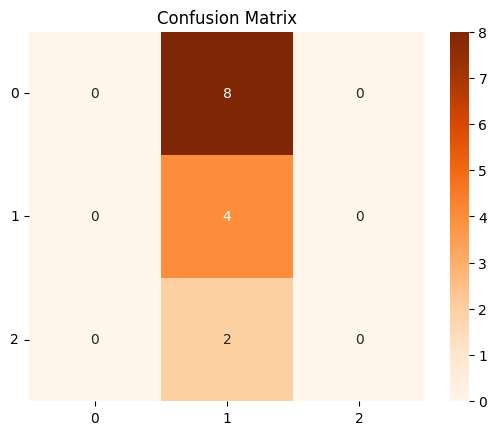

In [685]:
predictions = model1D.predict(X_test)

pred = np.argmax(predictions, axis=1)

CM = confusion_matrix(y_test, pred)
ax = plt.subplot()
sns.heatmap(CM, annot=True, ax=ax, fmt='g', cmap=plt.cm.Oranges)
plt.yticks(rotation=0)
ax.set_title("Confusion Matrix")

print(classification_report(y_test, pred))

**RNN(LSTM)**

RNN’s (LSTM’s) are pretty good at extracting patterns in input feature space, where the input data spans over long sequences. Given the gated architecture of LSTM’s that has this ability to manipulate its memory state, they are ideal for regression or time series problems.

In [691]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import *

X_train = np.clip(X_train, 0, 41)

input_ = Input(shape=(n_features,))
embedded = Embedding(42, 79, input_length= n_features)(input_)

lstm =LSTM(256, return_sequences=False)(embedded)
dense = Dense(4, activation='relu')(lstm)

lb = LabelBinarizer()
labelss = lb.fit_transform(y_train)

model2 = Model(input_, dense)
model2.summary()
model2.compile(loss="binary_crossentropy", optimizer='adam', metrics=['accuracy'])
H=model2.fit(X_train, labelss, epochs=5, batch_size=1, verbose=2)

Model: "model_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 11)]              0         
                                                                 
 embedding_11 (Embedding)    (None, 11, 79)            3318      
                                                                 
 lstm_10 (LSTM)              (None, 256)               344064    
                                                                 
 dense_44 (Dense)            (None, 4)                 1028      
                                                                 
Total params: 348410 (1.33 MB)
Trainable params: 348410 (1.33 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/5
52/52 - 6s - loss: 1.7343 - accuracy: 0.5000 - 6s/epoch - 108ms/step
Epoch 2/5
52/52 - 1s - loss: 1.7032 - accuracy: 0.4231 - 674ms/epoch - 13ms

1/1 [==============================] - 0s 330ms/step


Text(0.5, 1.0, 'Confusion Matrix')

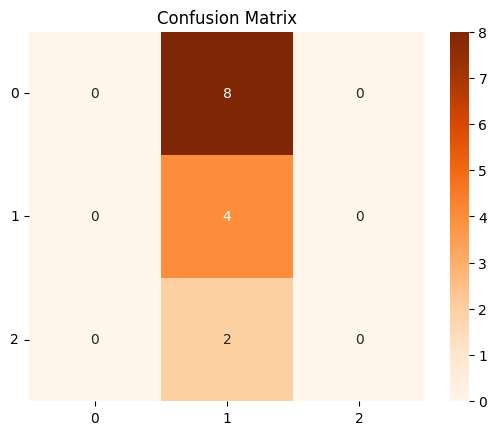

In [693]:
X_test = np.clip(X_test, 0, 41)

predictions - model2.predict(X_test)
pred = np.argmax(predictions, axis=1)
CM = confusion_matrix(y_test, pred)

ax = plt.subplot()
sns.heatmap(CM, annot=True, fmt='g', ax=ax, cmap=plt.cm.Oranges)
plt.yticks(rotation=0)
ax.set_title("Confusion Matrix")

**Save trained model**


Since the machine learning model has been trained, we can now save this model with pickle.

In [696]:
# To pickle or save the ml model
import pickle
import os

file_path = "./result/crime_prediction.pickle"
os.makedirs("result", exist_ok=True)

pickle_out = open(file_path, 'wb')
pickle.dump(model2, pickle_out)
pickle_out.close()

In [697]:
# Using model training

if os.path.exists(file_path):
    try:
        with open(file_path, 'rb') as pickle_in:
            model = pickle.load(pickle_in)
        print("Model loaded successfully.")
    except Exception as e:
        print(f"Error loading the model: {e}")
else:
    print("Error: Model not found.")

Model loaded successfully.
